   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 51.5 MB/s eta 0:00:00
⚡ Carregando modelo em: CUDA...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

📦 Carregando LCM-LoRA...


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ LCM-LoRA aplicado!
🎨 Gerando imagem...


  0%|          | 0/4 [00:00<?, ?it/s]

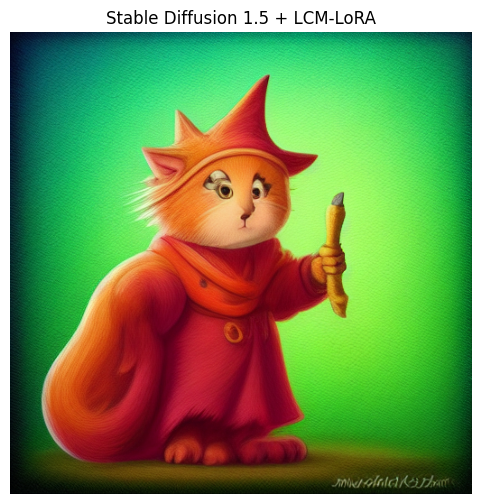

✅ Concluído!


In [4]:
# ============================================================
# INSTALAÇÃO
# ============================================================

!pip uninstall -y torchao -q
!pip install -q -U diffusers transformers accelerate peft

# IMPORTAÇÕES

import torch
from diffusers import StableDiffusionPipeline, LCMScheduler
import matplotlib.pyplot as plt


# ============================================================
# 1. CARREGA O STABLE DIFFUSION 1.5
# ============================================================

model_id = "runwayml/stable-diffusion-v1-5"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"⚡ Carregando modelo em: {device.upper()}...")

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    use_safetensors=True
)

pipe = pipe.to(device)


# ============================================================
# 2. CARREGA O LCM-LoRA
# ============================================================

print("📦 Carregando LCM-LoRA...")

pipe.load_lora_weights(
    "latent-consistency/lcm-lora-sdv1-5",
    adapter_name="lcm"
)

# Scheduler apropriado para LCM
pipe.scheduler = LCMScheduler.from_config(
    pipe.scheduler.config
)

print("✅ LCM-LoRA aplicado!")


# ============================================================
# 3. GERA A IMAGEM
# ============================================================

prompt = """
a cute wizard cat casting a spell,
digital art,
highly detailed
"""

print("🎨 Gerando imagem...")

image = pipe(
    prompt=prompt,
    num_inference_steps=4,
    guidance_scale=1.0
).images[0]


# ============================================================
# 4. EXIBE
# ============================================================

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Stable Diffusion 1.5 + LCM-LoRA")
plt.show()

print("✅ Concluído!")